In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# Load the enhanced dataset
df = pd.read_csv("../../data/processed/toxiguard_with_engineered_features.csv")

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"\n📊 Shape: {df.shape}")
print(f"\n📋 Columns:")
for col in df.columns:
    print(f"  • {col}")

# Check for any missing values
print(f"\nMissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Basic info
print(f"\n📝 Data types:")
print(df.dtypes)

DATASET OVERVIEW

📊 Shape: (52768, 19)

📋 Columns:
  • text
  • toxic
  • source
  • char_count
  • word_count
  • sentence_count
  • exclamation_count
  • question_count
  • period_count
  • all_caps_words
  • caps_ratio
  • sentiment_compound
  • sentiment_positive
  • sentiment_negative
  • sentiment_neutral
  • sentiment_category
  • flesch_score
  • fog_index
  • smog_index

Missing values:
Series([], dtype: int64)

📝 Data types:
text                   object
toxic                   int64
source                 object
char_count              int64
word_count              int64
sentence_count          int64
exclamation_count       int64
question_count          int64
period_count            int64
all_caps_words          int64
caps_ratio            float64
sentiment_compound    float64
sentiment_positive    float64
sentiment_negative    float64
sentiment_neutral     float64
sentiment_category     object
flesch_score          float64
fog_index             float64
smog_index           

In [3]:
print("="*60)
print("SELECTING NUMERICAL FEATURES")
print("="*60)

# List of features to EXCLUDE from correlation analysis
exclude_features = ['toxic', 'text', 'source', 'sentiment_category']

# Get all numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n🔢 All numerical columns: {numerical_cols}")

# Filter to keep only feature columns (exclude target and any others)
feature_cols = [col for col in numerical_cols if col not in exclude_features]
print(f"\n✨ Feature columns for correlation analysis ({len(feature_cols)}):")
for col in feature_cols:
    print(f"  • {col}")

# Quick statistics of features
print("\n📊 Feature statistics:")
print(df[feature_cols].describe().round(3))

SELECTING NUMERICAL FEATURES

🔢 All numerical columns: ['toxic', 'char_count', 'word_count', 'sentence_count', 'exclamation_count', 'question_count', 'period_count', 'all_caps_words', 'caps_ratio', 'sentiment_compound', 'sentiment_positive', 'sentiment_negative', 'sentiment_neutral', 'flesch_score', 'fog_index', 'smog_index']

✨ Feature columns for correlation analysis (15):
  • char_count
  • word_count
  • sentence_count
  • exclamation_count
  • question_count
  • period_count
  • all_caps_words
  • caps_ratio
  • sentiment_compound
  • sentiment_positive
  • sentiment_negative
  • sentiment_neutral
  • flesch_score
  • fog_index
  • smog_index

📊 Feature statistics:
       char_count  word_count  sentence_count  exclamation_count  \
count   52768.000   52768.000       52768.000          52768.000   
mean      172.592      29.744           3.061              0.180   
std       215.478      36.995           2.689              0.745   
min        10.000       1.000           1.000    

CORRELATION WITH TARGET (TOXICITY)

📊 Features ranked by correlation with toxicity:
           feature  correlation
sentiment_negative       0.4618
    sentence_count      -0.3995
 sentiment_neutral      -0.3825
        word_count      -0.3794
        char_count      -0.3762
sentiment_compound      -0.3595
      period_count      -0.3108
        smog_index      -0.2965
         fog_index      -0.2216
      flesch_score       0.1868
    question_count      -0.1613
        caps_ratio       0.1184
sentiment_positive      -0.0715
    all_caps_words      -0.0211
 exclamation_count      -0.0079


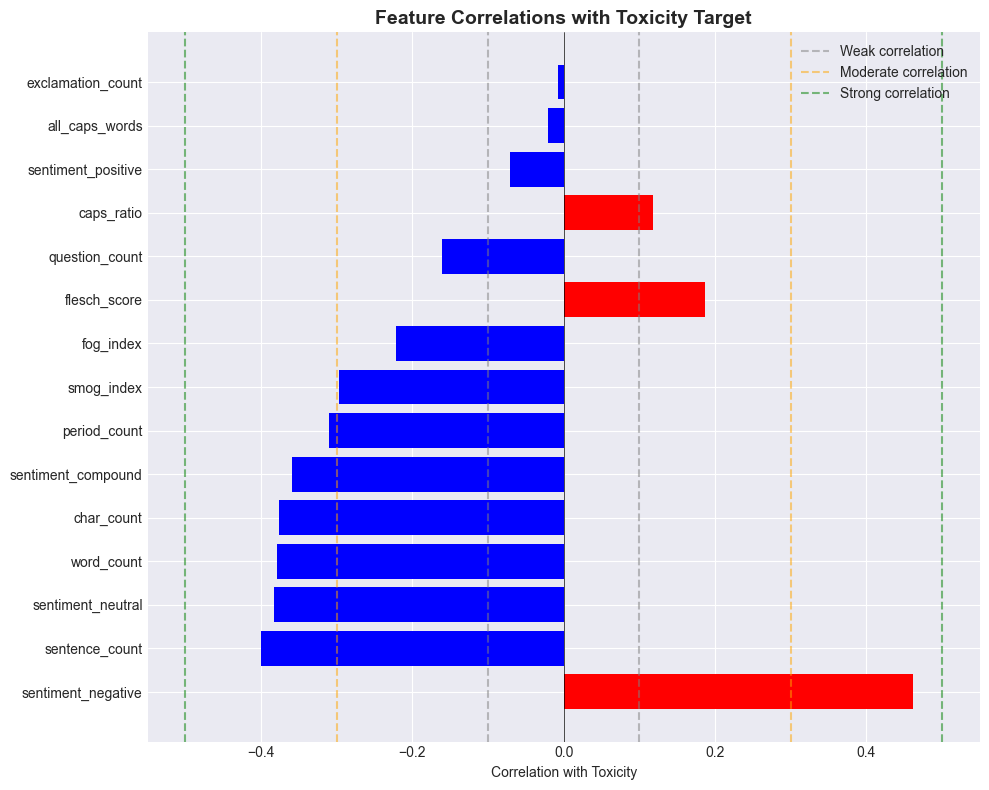


💡 Key Insights:
  • Strongest positive correlation: sentiment_negative (0.462)
  • Strongest negative correlation: exclamation_count (-0.008)


In [4]:
print("="*60)
print("CORRELATION WITH TARGET (TOXICITY)")
print("="*60)

# Calculate correlation of each feature with toxicity
target_correlations = []
for col in feature_cols:
    corr = df['toxic'].corr(df[col])
    target_correlations.append({
        'feature': col,
        'correlation': corr,
        'abs_correlation': abs(corr)
    })

# Create dataframe and sort by absolute correlation
corr_target_df = pd.DataFrame(target_correlations)
corr_target_df = corr_target_df.sort_values('abs_correlation', ascending=False)

print("\n📊 Features ranked by correlation with toxicity:")
print(corr_target_df[['feature', 'correlation']].round(4).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))

# Color based on positive/negative correlation
colors = ['red' if x > 0 else 'blue' for x in corr_target_df['correlation']]

plt.barh(range(len(corr_target_df)), corr_target_df['correlation'], color=colors)
plt.yticks(range(len(corr_target_df)), corr_target_df['feature'])
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='Weak correlation')
plt.axvline(x=-0.1, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Moderate correlation')
plt.axvline(x=-0.3, color='orange', linestyle='--', alpha=0.5)
plt.axvline(x=0.5, color='green', linestyle='--', alpha=0.5, label='Strong correlation')
plt.axvline(x=-0.5, color='green', linestyle='--', alpha=0.5)

plt.xlabel('Correlation with Toxicity')
plt.title('Feature Correlations with Toxicity Target', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('../../results/figures/target_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n💡 Key Insights:")
print(f"  • Strongest positive correlation: {corr_target_df.iloc[0]['feature']} ({corr_target_df.iloc[0]['correlation']:.3f})")
print(f"  • Strongest negative correlation: {corr_target_df.iloc[-1]['feature']} ({corr_target_df.iloc[-1]['correlation']:.3f})")

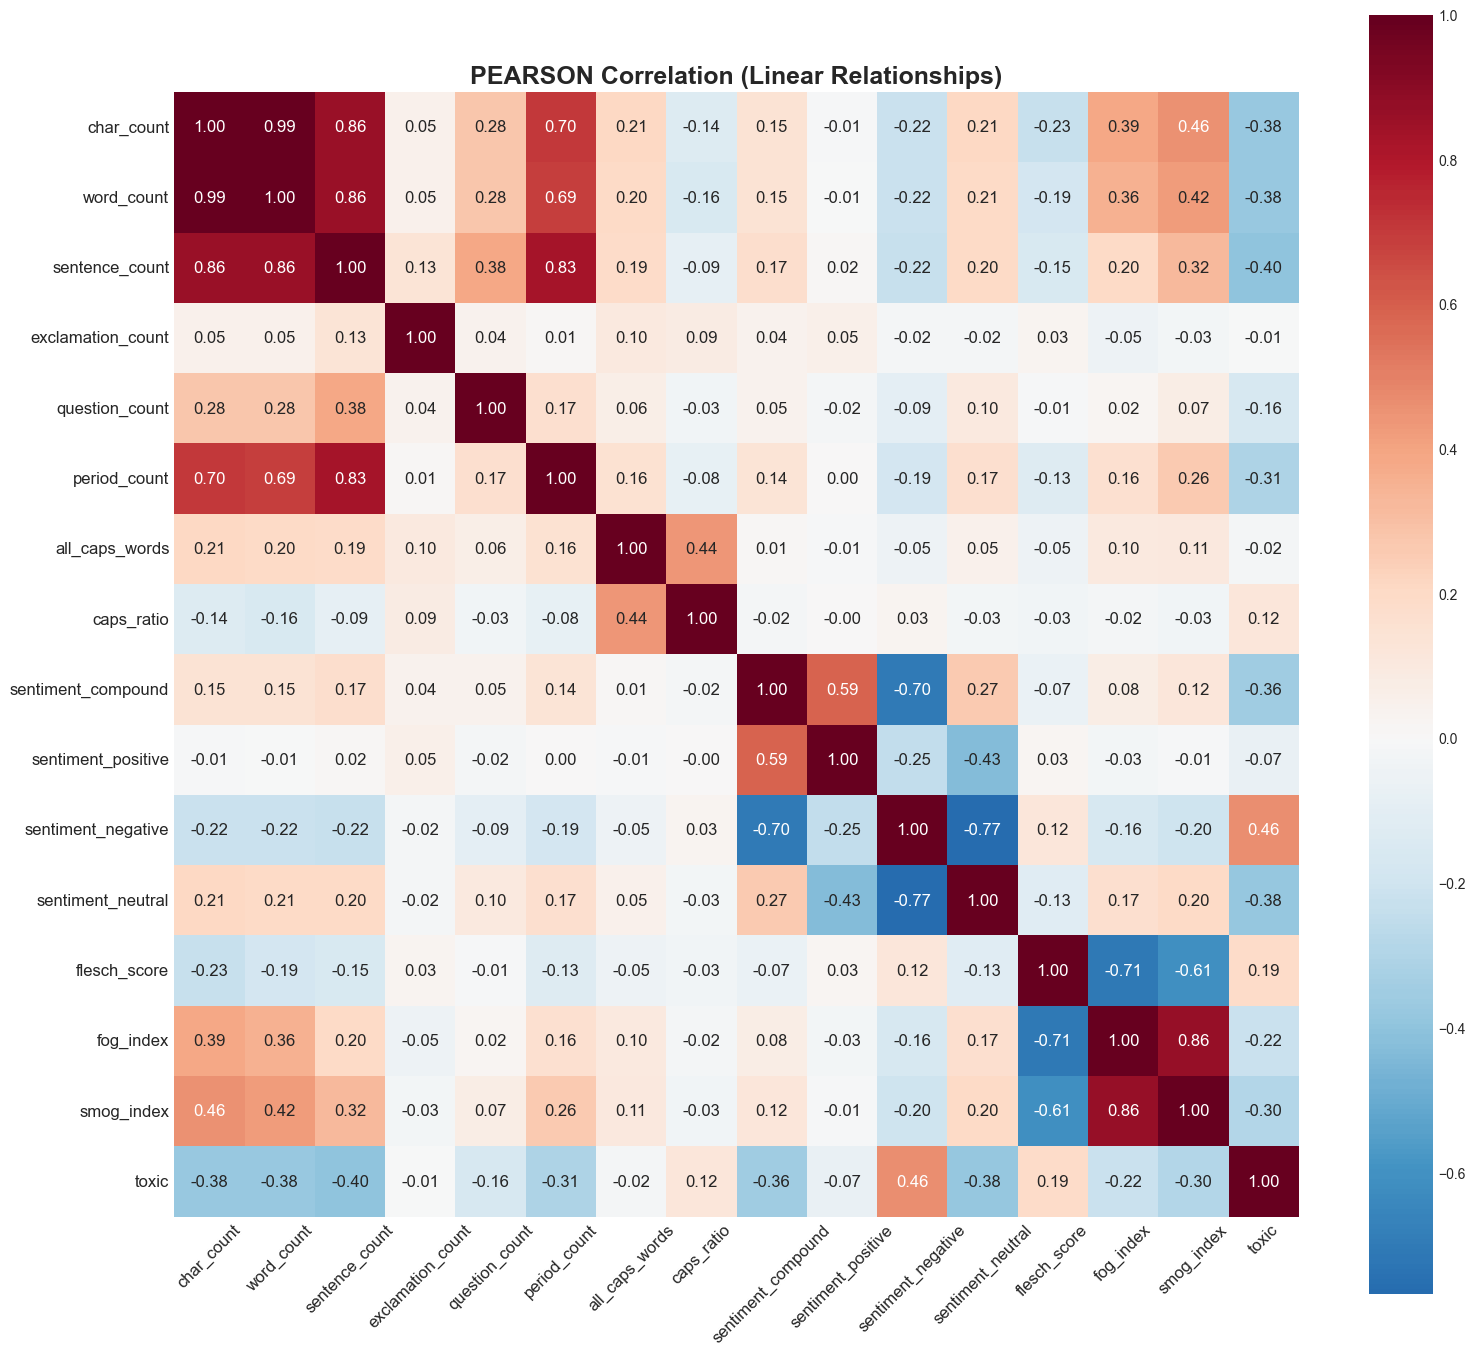

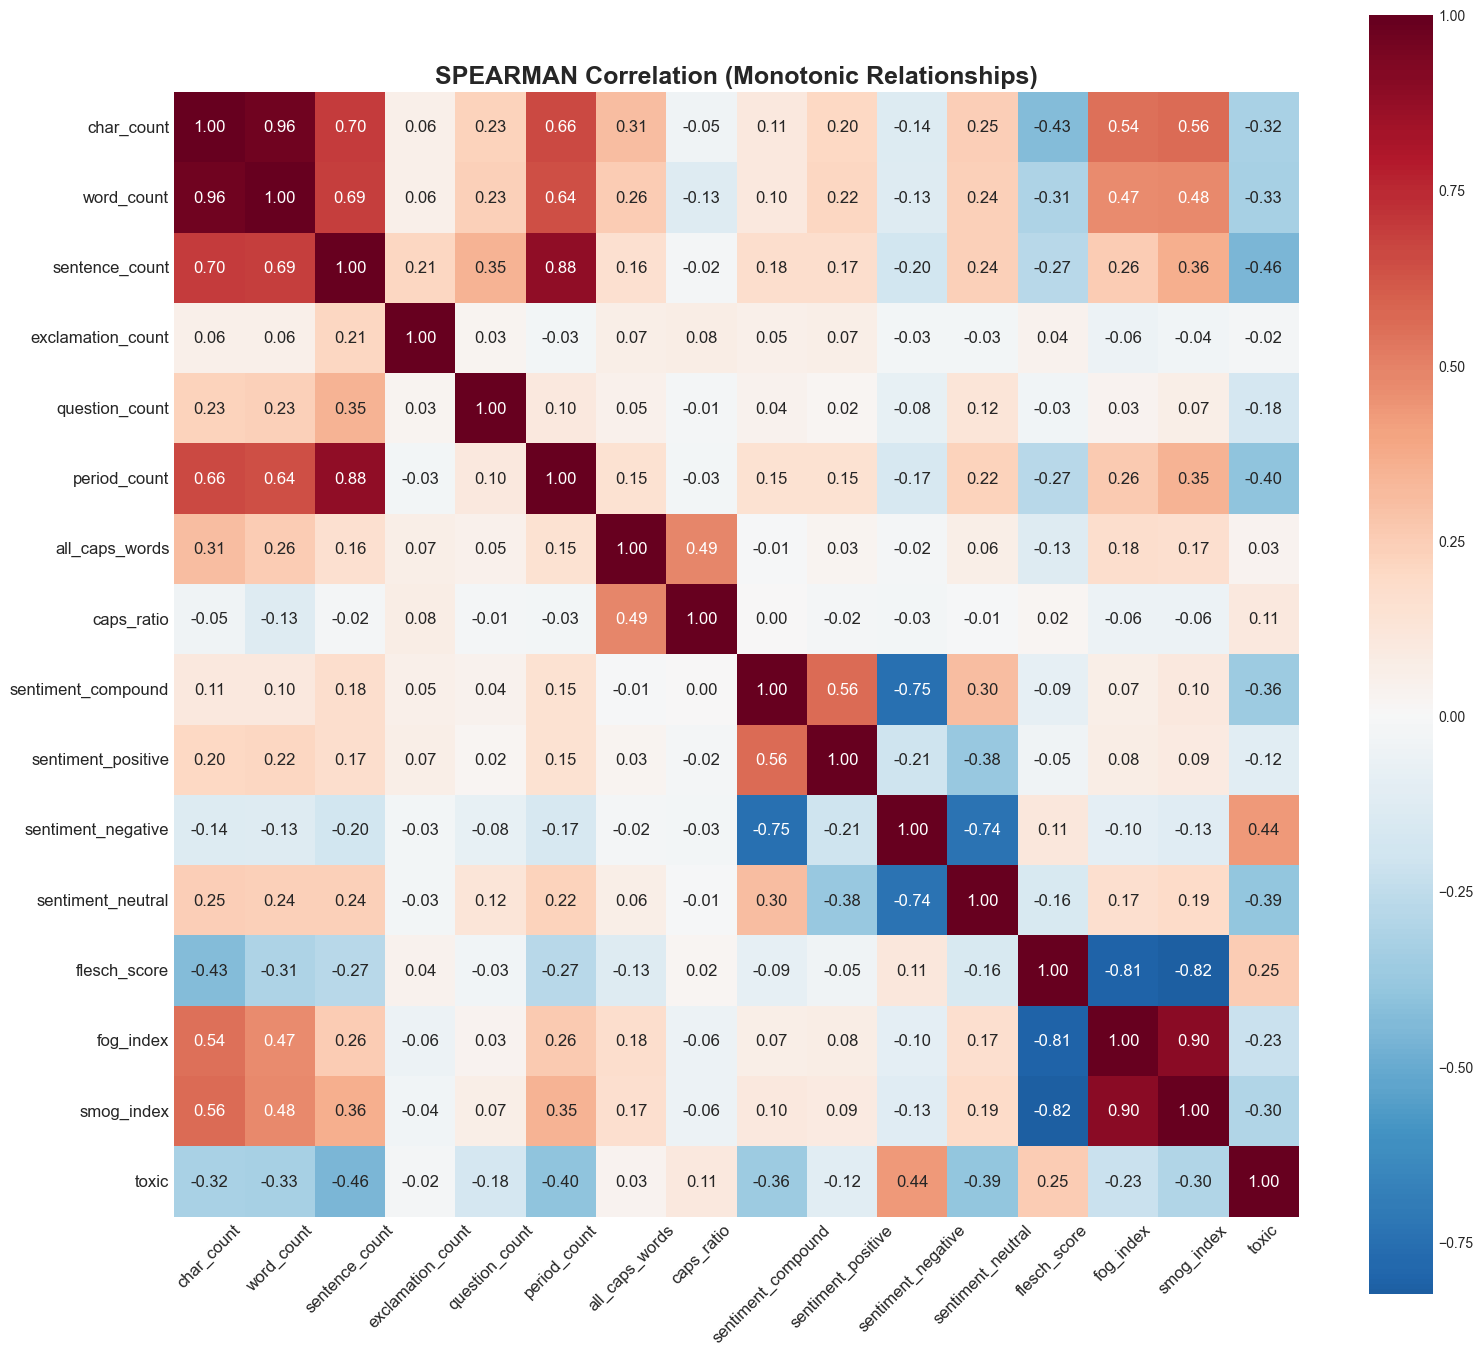

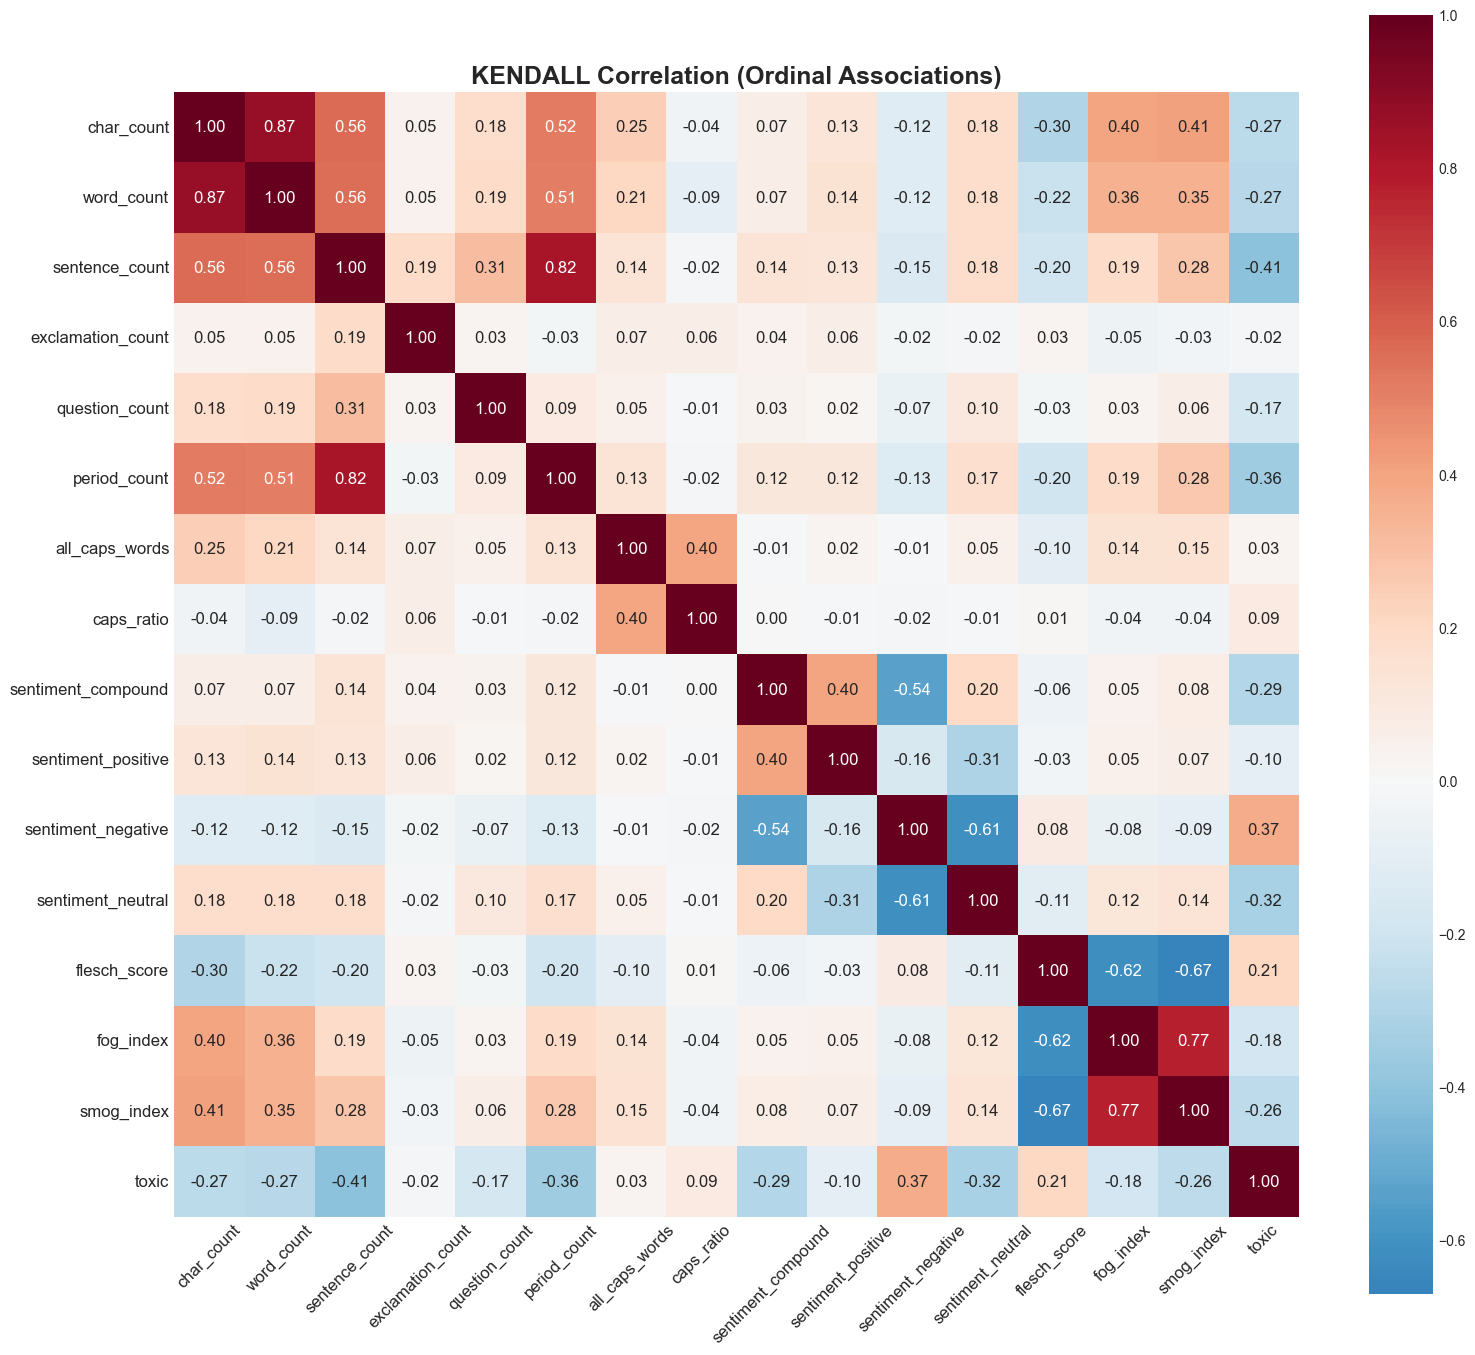

In [9]:
# ---------------- PEARSON HEATMAP ----------------
plt.figure(figsize=(16,14))

sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    annot_kws={"size":12}
)

plt.title('PEARSON Correlation (Linear Relationships)', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig('../../results/figures/pearson_correlation_matrix.png',
            dpi=300, bbox_inches='tight')

plt.show()



# ---------------- SPEARMAN HEATMAP ----------------
plt.figure(figsize=(16,14))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    annot_kws={"size":12}
)

plt.title('SPEARMAN Correlation (Monotonic Relationships)', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig('../../results/figures/spearman_correlation_matrix.png',
            dpi=300, bbox_inches='tight')

plt.show()



# ---------------- KENDALL HEATMAP ----------------
plt.figure(figsize=(16,14))

sns.heatmap(
    kendall_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    annot_kws={"size":12}
)

plt.title('KENDALL Correlation (Ordinal Associations)', fontsize=18, fontweight='bold')
plt.xticks(fontsize=12, rotation=45)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.savefig('../../results/figures/kendall_correlation_matrix.png',
            dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
#Based on the correlation analysis, a simple feature selection process will be executed:
##Droping the features with the least correlation coefficient with the target "toxic":
###features to be dropped: sentence_count,period_count,all_caps_words,sentiment_compound.